# 🎮 Mobile Game Retention Analysis

This project analyzed user behavior to understand retention, churn, and engagement in a mobile game.

## 1. Project Introduction

### Objective
This project analyzes player behavior in a mobile game to understand user retention patterns, engagement levels, and player segmentation.

The goal is to identify how players interact with the game over time and provide actionable product insights.

### Data Description

Two datasets are used:

#### users table
- user_id: unique player identifier
- install_date: date when the player installed the game
#### events table
- user_id: unique player identifier
- event_date: date of in-game activity
- event_type: type of in-game event (session_start)

## 2. Data Loading & Cleaning

### 2.1 Load datasets

In [38]:
import pandas as pd

# import datasets
users = pd.read_excel(r"C:\Users\lyrgl\Desktop\mobile game data\users.xlsx")
events = pd.read_excel(r"C:\Users\lyrgl\Desktop\mobile game data\events.xlsx")

### 2.2 Data types & preprocessing

- Convert date columns to datetime
- Merge datasets on `user_id`

In [39]:
# transform time form
users['install_date'] = pd.to_datetime(users['install_date'])
events['event_date'] = pd.to_datetime(events['event_date'])

# merge
df = events.merge(users, on='user_id', how='left')

df.head()

,user_id,event_date,event_type,install_date
0,1,2024-01-07,session_start,2024-01-07
1,1,2024-01-08,session_start,2024-01-07
2,1,2024-01-09,session_start,2024-01-07
3,1,2024-01-10,session_start,2024-01-07
4,1,2024-01-11,session_start,2024-01-07


### 2.3 DAU, MAU

In [97]:
# DAU - Daily Active Users
# How many unique players played today?

dau = events.groupby('event_date')['user_id'].nunique()
display(dau)

event_date
2024-01-01    169
2024-01-02    313
2024-01-03    439
2024-01-04    529
2024-01-05    603
             ... 
2024-03-01      2
2024-03-02      2
2024-03-03      1
2024-03-04      1
2024-03-05      1
Name: user_id, Length: 65, dtype: int64

In [98]:
# MAU - Monthly Active Users
# How many players played this month at least once?
events['month'] = events.event_date.dt.to_period('M')
mau = events.groupby("month")["user_id"].nunique()

mau

month
2024-01    5000
2024-02     624
2024-03       2
Freq: M, Name: user_id, dtype: int64

## 3 Retention Analysis
Objective:

Understand how player retention evolves over time after installation.

### 3.1 retention metrics
- Create `days_since_install`

In [107]:
df['days_since_install'] = (df['event_date'] - df['install_date']).dt.days

In [134]:
def retention(day):
    return (
        df[df.days_since_install == day]["user_id"].nunique()
        / users["user_id"].nunique()
    )

retention_metrics = {
    "D1": retention(1),
    "D7": retention(7),
    "D30": retention(30)
}

In [135]:
print(retention_metrics)

{'D1': 0.8188, 'D7': 0.2422, 'D30': 0.0024}


In [136]:
retention_df = pd.DataFrame(retention_metrics.items(), columns=["Metric", "Retention Rate"])
retention_df

,Metric,Retention Rate
0,D1,0.8188
1,D7,0.2422
2,D30,0.0024


In [137]:
retention_df["Retention Rate (%)"] = retention_df["Retention Rate"] * 100
retention_df

,Metric,Retention Rate,Retention Rate (%)
0,D1,0.8188,81.88
1,D7,0.2422,24.22
2,D30,0.0024,0.24


<Axes: title={'center': 'D1 / D7 / D30 Retention'}, xlabel='Metric'>

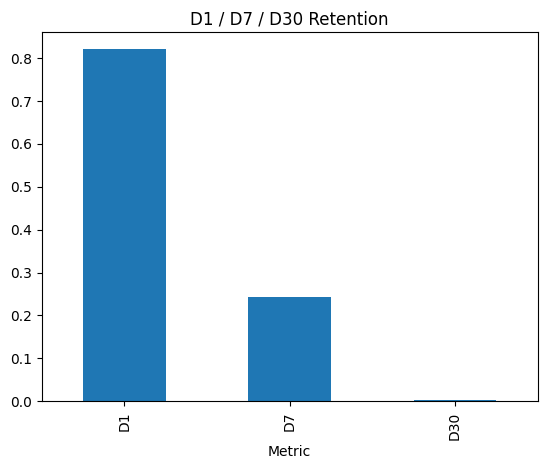

In [139]:
retention_df.set_index("Metric")["Retention Rate"].plot(
    kind="bar",
    title="D1 / D7 / D30 Retention"
)

### 3.2 Retention Curve (Overall Behavior)

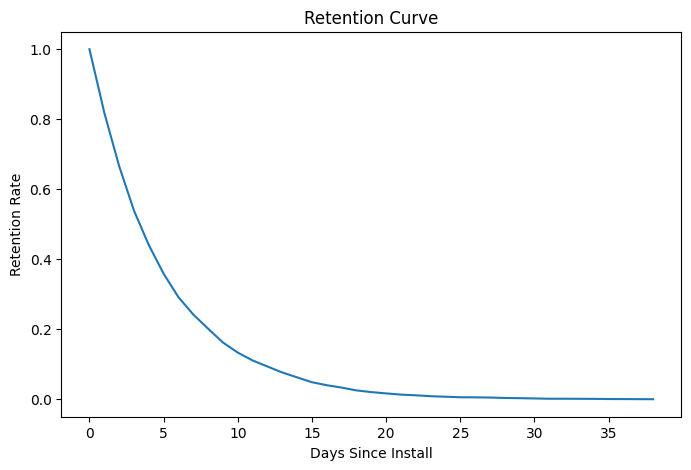

In [138]:
retention_curve = (
    df.groupby("days_since_install")["user_id"]
    .nunique()
    / df["user_id"].nunique()
)


import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
retention_curve.plot()
plt.title("Retention Curve")
plt.xlabel("Days Since Install")
plt.ylabel("Retention Rate")
plt.show()

## 3. Cohort Analysis

### 3.1 Cohort size calculation
Define number of users per install cohort.

In [41]:
cohort_size = users.groupby('install_date')['user_id'].nunique()
cohort_size.head()

install_date
2024-01-01    169
2024-01-02    176
2024-01-03    184
2024-01-04    168
2024-01-05    178
Name: user_id, dtype: int64

### 3.2 Retention rate

In [118]:
retention = retention.merge(cohort_size.rename('cohort_size'), on='install_date')

retention['retention_rate'] = retention['user_id']/retention['cohort_size']

### 3.3 Cohort heatmap
- Compare retention across install cohorts

In [44]:
cohort_pivot = retention.pivot_table(
    index='install_date',
    columns='days_since_install',
    values='retention_rate'
)

cohort_pivot.head()

days_since_install,0,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,35,36,37,38
install_date,,,,,,,,,,,,,,,,,,,,,
2024-01-01,1.0,0.810651,0.644970,0.544379,0.443787,0.325444,0.278107,0.242604,0.218935,0.177515,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-02,1.0,0.829545,0.664773,0.500000,0.414773,0.340909,0.301136,0.238636,0.198864,0.147727,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-03,1.0,0.826087,0.657609,0.521739,0.396739,0.309783,0.250000,0.206522,0.152174,0.108696,...,0.005435,0.005435,0.005435,0.005435,0.005435,0.005435,NaN,NaN,NaN,NaN
2024-01-04,1.0,0.839286,0.654762,0.505952,0.392857,0.327381,0.214286,0.184524,0.130952,0.113095,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-01-05,1.0,0.769663,0.657303,0.522472,0.443820,0.348315,0.297753,0.247191,0.196629,0.140449,...,0.005618,0.005618,0.005618,0.005618,0.005618,NaN,NaN,NaN,NaN,NaN


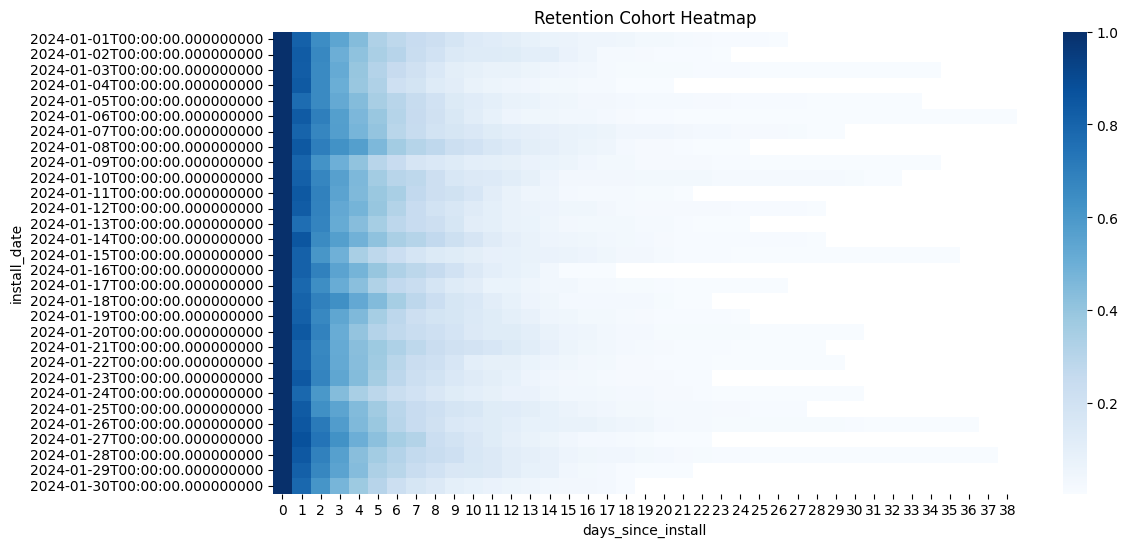

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.heatmap(cohort_pivot, cmap="Blues")
plt.title('Retention Cohort Heatmap')
plt.show()

### 3.4 Key Insights
- Strong Day 1 retention indicates effective onboarding
- Significant drop occurs between Day 2–Day 3
- Retention continues to decline but stabilizes at a low baseline

## 4. Engagement Analysis

Objective:

Understand how frequently players engage with the game.

### 4.1 Sessions per User


In [53]:
user_activity = df.groupby('user_id').size().reset_index(name='total_sessions')

### 4.2 Distribution of Engagement

<Axes: >

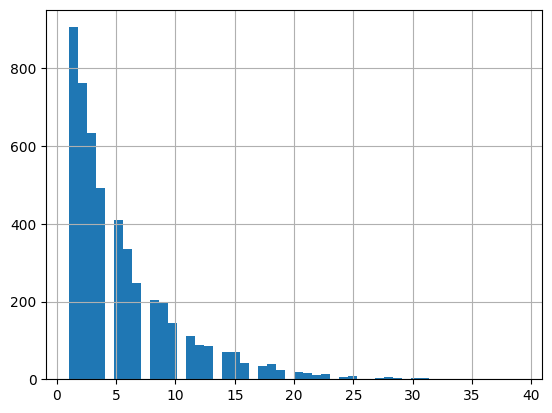

In [60]:
user_activity['total_sessions'].hist(bins=50)

### 4.3 Insights
- Engagement is highly skewed
- A small group of players accounts for most activity

## 5. Player Segmentation

Objective: Segement players based on engagment level.

### 5.1 Create Segments

In [54]:
user_activity['segment'] = pd.qcut(user_activity['total_sessions'],q=3, labels=['low', 'medium', 'high'])

user_activity.head()

,user_id,total_sessions,segment
0,1,6,medium
1,2,4,medium
2,3,11,high
3,4,2,low
4,5,6,medium


### 5.2 Segment Distribution

In [64]:
segment_summary = user_activity['segment'].value_counts().reset_index()
segment_summary.columns = ['segment', 'count']

segment_summary['share'] = segment_summary['count'] / segment_summary['count'].sum()

segment_summary

,segment,count,share
0,medium,1873,0.3746
1,low,1669,0.3338
2,high,1458,0.2916


## 6. Segment-Level Retention Analysis
Objective:
 Analyze how retention behavior differs across player engagement segments

### 6.1 Daily Users Table

In [82]:
daily_users = df[['user_id', 'install_date', 'event_date']].drop_duplicates()

daily_users['days_since_install'] = (
    daily_users['event_date'] - daily_users['install_date']
).dt.days

In [83]:
daily_users = daily_users.merge(
    user_activity[['user_id', 'segment']],
    on='user_id',
    how='left'
)

### 6.2 Build Segment-Level Retention Table

In [84]:
seg_retention = daily_users.groupby(
    ['segment', 'install_date', 'days_since_install']
)['user_id'].nunique().reset_index()

C:\Users\lyrgl\AppData\Local\Temp\ipykernel_21804\1542748479.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seg_retention = daily_users.groupby(


### 6.3 Compute Segment Cohort Size

In [85]:
segment_cohort_size = daily_users.groupby(
    ['segment', 'install_date']
)['user_id'].nunique().reset_index()

segment_cohort_size.columns = ['segment', 'install_date', 'cohort_size']

C:\Users\lyrgl\AppData\Local\Temp\ipykernel_21804\1764195818.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_cohort_size = daily_users.groupby(


### 6.4 Merge Cohort Size

In [86]:
seg_retention = seg_retention.merge(
    segment_cohort_size,
    on=['segment', 'install_date'],
    how='left'
)

### 6.5 Calculate Retention Rate

In [87]:
seg_retention['retention_rate'] = (
    seg_retention['user_id'] / seg_retention['cohort_size']
)

### 6.6 Average Retention Curve by Segment

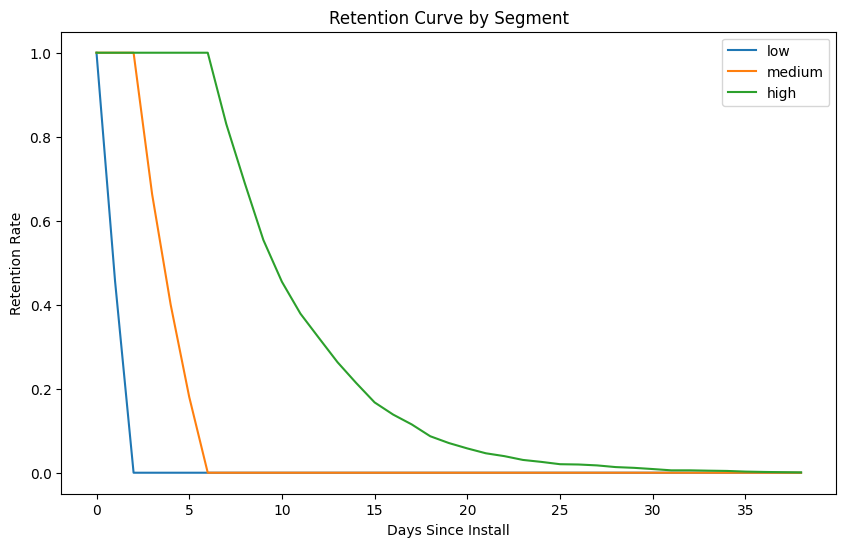

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for seg in seg_retention['segment'].unique():
    temp = seg_retention[seg_retention['segment'] == seg]
    avg_curve = temp.groupby('days_since_install')['retention_rate'].mean()
    plt.plot(avg_curve, label=seg)

plt.title("Retention Curve by Segment")
plt.xlabel("Days Since Install")
plt.ylabel("Retention Rate")
plt.legend()
plt.show()

retention_curve = seg_retention.groupby('days_since_install')['retention_rate'].mean()

### 5.4 Key Insights

- Low-engagement users drop off rapidly within the first 1–2 days
- Medium-engagement users show moderate retention decay, stabilizing around day ~6
- High-engagement users exhibit slow and sustained retention decline over 30+ days
- Engagement level is strongly correlated with long-term retention behavior


In [140]:
retention_export = retention_curve.reset_index()
retention_export.columns = ["days_since_install", "retention_rate"]

retention_export.to_csv("retention_curve.csv", index=False)

In [147]:
d1 = retention_curve.get(1)
d7 = retention_curve.get(7)
d30 = retention_curve.get(30)
dau = df.groupby('event_date')['user_id'].nunique().mean()
mau = df.groupby(df['event_date'].dt.to_period('M'))['user_id'].nunique().mean()

import pandas as pd

kpi = pd.DataFrame({
    "metric": ["dau", "mau", "d1_retention", "d7_retention", "d30_retention"],
    "value": [dau, mau, d1, d7, d30]
})

kpi.to_csv("kpi.csv", index=False)

In [141]:
cohort_pivot.to_csv("cohort_heatmap.csv")

In [143]:
segment_dist = user_activity['segment'].value_counts().reset_index()
segment_dist.columns = ["segment", "count"]

segment_dist.to_csv("segment_distribution.csv", index=False)

In [148]:
user_activity.to_csv("user_activity.csv", index=False)

In [149]:
seg_retention.to_csv("seg_retention.csv", index=False)